In [1]:
import os
import cv2
import torch
import random
import torchvision

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

import torchvision.models as models
import torchvision.datasets as datasets

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import log_softmax, ctc_loss
from torchvision.transforms.v2 import Resize, ToDtype, ToImage, Normalize, Compose, Grayscale

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import warnings
warnings.filterwarnings('ignore')

cuda


In [2]:
# Позаботимся о воспроизводимости
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

## > OCR. Распознавание штрихкодов

#### Описание задачи

Как и было обещано в практическом занятии, мы продолжим решать задачу распознавания штрихкодов. За основу возьмём код, реализованный на практике, и посмотрим, как можно его изменить. В отличие от задачи классификации кошек и собак или, например, детекции людей, наша задача довольно необычная и для неё нет стандартных способов решения. В этом задании мы посмотрим на задачу с разных сторон и попробуем разные способы улучшения нашего пайплайна.

#### План

- Реализация метрик качества WER и CER
- Настройка пайплайна обучения и тестирования
- Эксперимент. Подготовка данных, изменение датасета
- Эксперимент. Замена loss-функции



## > Реализация метрик качества
В контексте нашей задачи мы будем рассматривать 2 метрики:

- Word Error Rate (WER);
- Char Error Rate (CER).





#### WER

Первую метрику (WER) мы будем воспринимать как целевую метрику. В качестве слова мы будем рассматривать штрихкод целиком. Таким образом, нашей задачей является правильно распознать весь штрихкод, поскольку ошибка даже в одной цифре приводит к тому, что штрихкод становится неверным.

Мы могли бы в качестве целевой метрики взять Accuracy, но в распознавании текста принято учитывать долю ошибок, так как, помимо неправильно распознанных слов, в распознавание может попасть лишнее слово или, наоборот, какое-то слово может быть пропущено.

В нашем случае, когда в каждом примере присутствует только одно слово и модель выдаёт только одно предсказание, WER и Accuracy будут взаимозаменяемыми величинами.

**Задание 1**. Реализуйте функцию wer_score. Функция принимает два списка — предсказания модели и разметку, где каждый элемент в этих списках представляет собой строку с одним штрихкодом. Функция должна возвращать долю неверно распознанных штрихкодов в датасете.

In [3]:
from typing import List

def wer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики WER (Word Error Rate) для оценки качества распознавания штрихкодов.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return wer: Доля ошибочно распознанных штрихкодов (WER)
    """
    if not predictions:
        return 0.0

    errors = sum(1 for pred, gt in zip(predictions, ground_truth) if pred != gt)
    wer = errors / len(predictions)
    return wer

In [4]:
wer_score(["123", "ll"], ["sdf", "12"])

1.0

In [5]:
# Решение автора
def wer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики WER (Word Error Rate) для оценки качества распознавания штрихкодов.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return wer: Доля ошибочно распознанных штрихкодов (WER)
    """
    incorrect_count = 0
    for predict, gt in zip(predictions, ground_truth):
        if predict != gt:
          incorrect_count += 1
    if len(predictions) != 0:
      wer = incorrect_count/len(predictions)
    else:
      wer = 0
    return wer

#### CER

Вторая метрика — CER (Character Error Rate) — показывает, насколько точно модель распознаёт символы внутри штрихкода. Она полезна для более детального сравнения различных моделей, особенно когда WER (метрика ошибок на уровне штрихкода) одинакова.

Предположим, мы только начали обучать разные варианты моделей и при тестировании видим, что обе они плохо справляются с задачей и ошибаются на каждом примере, то есть у них будет WER = 1. При этом если мы внимательно посмотрим на предсказания моделей, то увидим, что первая модель в примере ошибается в одном или двух символах, а другая просто выдаёт случайную последовательность чисел.

Несмотря на то что обе модели не решают конечную задачу, явно имеет смысл попробовать улучшить первую модель, так как видно, что она лучше справляется с задачей.

Таким образом, метрика CER помогает нам более наглядно сравнивать модели между собой.

CER можно рассчитать как отношение расстояния Левенштейна к количеству символов в строке. Я предлагаю сейчас не останавливаться на реализации расстояния Левенштейна, а взять готовую реализацию (но советую вам посмотреть реализацию и разобраться, зачем на курсах по алгоритмам рассказывают про динамическое программирование).

Будем использовать реализацию алгоритма из библиотеки levenshtein.

In [6]:
!pip install levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.0 MB/s eta 0:00:00a 0:00:01


Пример использования библиотеки levenshtein:

In [7]:
import Levenshtein

predict = "12345"
gt = "1234"

distance = Levenshtein.distance(predict, gt)
print(distance)

1


**Задание 2**. Реализуйте функцию cer_score. Функция принимает два списка — предсказания модели и разметку, где каждый элемент в этих списках представляет собой строку с одним штрихкодом. Функция должна возвращать долю ошибок на уровне символов (CER) для всего датасета *(как будто мы «вытянули» все предсказания в одну строчку и сравнили с такой же «вытянутой» строчкой разметки)*.


In [8]:
import Levenshtein
from typing import List

def cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики CER (Character Error Rate), которая измеряет точность распознавания символов
    в штрихкодах, используя расстояние Левенштейна.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return cer (float): Доля ошибок на уровне символов (CER) для всего датасета
    """
    errors = 0
    reference = 0
    
    for predict, gt in zip(predictions, ground_truth):
        errors +=  Levenshtein.distance(predict, gt)
        reference += len(gt)
    if not reference:
        return 0.0

    cer = errors/reference
    return cer


In [9]:
cer_score(["123", "ll"], ["sdf", "12"])

1.0

In [10]:
# Решение автора
def cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики CER (Character Error Rate), которая измеряет точность распознавания символов
    в штрихкодах, используя расстояние Левенштейна.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return cer (float): Доля ошибок на уровне символов (CER) для всего датасета
    """
    sum_distance = 0
    sum_len = 0
    for predict, gt in zip(predictions, ground_truth):
        sum_distance += Levenshtein.distance(predict, gt)
        sum_len += len(gt)
    if sum_len == 0:
        cer = sum_distance 
    else:
        cer = sum_distance/sum_len
    return cer

Также полезно отслеживать среднее значение CER по каждой паре предиктов и разметки. Если грубые ошибки возникают в небольшом количестве случав при большом количестве примеров, это может затеряться при подсчёте CER по всему датасету, так как такие ошибки будут вносить небольшой вклад в итоговый результат. Поэтому полезно следить за средним значением, если оно значительно выше, значит, где-то есть «выбросы» с плохим качеством распознавания.

> Всё то же самое актуально и для WER, но в данном случае интереснее рассмотреть CER, так как значения WER в наших примерах всегда будут либо, 0 либо 1.

**Задание 3**. Реализуйте функцию mean_cer_score. Функция должна принимать два списка — предсказания модели и разметку, где каждый элемент в этих списках представляет собой строку с одним штрихкодом. Функция должна возвращать среднюю долю ошибок на уровне символов (средний CER) по всем парам предиктов и разметки.

In [11]:
import Levenshtein
from typing import List

def mean_cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления среднего значения CER по всем парам предикатов и разметки.

    :param predictions: Список строк, представляющих предсказания модели
    :param ground_truth: Список строк, представляющих истинные значения (разметку)

    :return: Среднее значение CER по всем парам
    """
    if len(ground_truth) == 0:
        return 0.0
    
    mean_error = 0.0
    for predict, gt in zip(predictions, ground_truth):
        # Используем max(len(gt), 1), чтобы избежать деления на ноль
        # и корректно обработать случай пустого GT
        error = Levenshtein.distance(predict, gt) / max(len(gt), 1)
        mean_error += error
    
    mean_cer = mean_error / len(ground_truth)
    return mean_cer

In [12]:
mean_cer_score(["123", "ll", ""], ["sdf", "l1", ""])

0.5

In [13]:
# Решение автора
def mean_cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления среднего значения CER по всем парам предикатов и разметки.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return cer (float): Доля ошибок на уровне символов (CER) для всего датасета
    """
    cer = []
    for predict, gt in zip(predictions, ground_truth):
        distance = Levenshtein.distance(predict, gt)
        if len(gt) != 0:
            current_cer = distance / len(gt)
        else:
            current_cer = distance  
        cer.append(current_cer)
    mean_cer = sum(cer)/len(cer)
    
    return mean_cer

## > Настройка пайплайна обучения и тестирования

Теперь мы можем оценивать качество наших моделей. Давайте повторим обучение из практического задания и посчитаем WER и CER для полученной модели.

Скопируем код из практического занятия, немного изменив его, чтобы нам было удобнее в будущем менять какие-то из этапов пайплайна.

In [14]:
def get_dataset(df_ann):
    unique_codes = sorted(np.unique(df_ann['code']))
    
    codes_for_train = random.sample(unique_codes, int(len(unique_codes) * 0.9))
    codes_for_test = list(set(unique_codes) - set(codes_for_train))
    
    df_train = df_ann[df_ann['code'].isin(codes_for_train)]
    df_test = df_ann[df_ann['code'].isin(codes_for_test)]
    
    df_train.reset_index(inplace=True, drop=True)
    df_test.reset_index(inplace=True, drop=True)
    
    df_train.reset_index(inplace=True, drop=True)
    df_test.reset_index(inplace=True, drop=True)
    return df_train, df_test

In [15]:
class RecognitionDataset(Dataset):
    def __init__(self, df, root, alphabet, transforms=None):
        super(RecognitionDataset, self).__init__()
        self.df = df
        self.root = root
        self.alphabet = alphabet
        self.image_names, self.texts = self._parse_root_()
        self.transforms = transforms

    def _parse_root_(self):
        image_names, texts = [], []
        for _, item in self.df.iterrows():
            image_name = os.path.join(self.root, item['imname'])
            text = str(item['code'])
            texts.append(text)
            image_names.append(image_name)
        return image_names, texts

    # Вот тут для символа возвращаем его индекс в алфавите
    def _text_to_seq_(self, text):
        seq = [self.alphabet.find(c) + 1 for c in text]
        return seq

    def __getitem__(self, item):
        pil_image = Image.open(self.image_names[item])
        torch_image = self.transforms(pil_image)
        text = self.texts[item]
        seq  = self._text_to_seq_(text)
        seq_len = len(seq)

        output  = dict(torch_image=torch_image, pil_image=pil_image, seq=seq, seq_len=seq_len, text=text)
        return output

    def __len__(self):
        return len(self.texts)


def collate_fn(batch):
    torch_images, pil_images, seqs, seq_lens, texts = [], [], [], [], []

    for item in batch:
        torch_images.append(item['torch_image'])
        pil_images.append(item['pil_image'])
        seqs.extend(item['seq'])
        seq_lens.append(item['seq_len']) # собрали список из последовательностей
        texts.append(item['text'])

    torch_images = torch.stack(torch_images)
    pil_images   = pil_images
    seqs         = torch.Tensor(seqs).int() # стекнули последовательности вместе, CTC Loss потом разберётся благодаря seq_lens
    seq_lens     = torch.Tensor(seq_lens).int()

    return {'torch_images': torch_images, 'pil_images':pil_images, 'seq': seqs, 'seq_len': seq_lens, 'text': texts}

In [16]:
def get_dataloaders(df_train, df_test, RecognitionDataset, images_path, batch_size, alphabet, transforms, collate_fn):
    train_dataset = RecognitionDataset(df_train, images_path,  alphabet=alphabet, transforms=transforms)
    test_dataset = RecognitionDataset(df_test, images_path,  alphabet=alphabet, transforms=transforms)
    
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True, collate_fn=collate_fn)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)
    return train_dataloader, test_dataloader


In [17]:
class Encoder(nn.Module):
    def __init__(self, input_size=(64, 224), output_len=28):
        super(Encoder, self).__init__()
        h, w = input_size
        resnet = getattr(models, 'resnet50')(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AvgPool2d(kernel_size=(h // 32, 1))   # сделали пулинг по высоте и получили 1 x 7 x C
        self.proj = nn.Conv2d(w // 32, output_len, kernel_size=1) # с помощью проекции получим 1 x output_len x C

        self.num_output_features = self.cnn[-1][-1].bn3.num_features


    def apply_projection(self, x):
        x = x.permute(0, 3, 2, 1).contiguous() # Поменяли размерности, чтобы применить self.proj
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1).contiguous() # Вернули размерности на место

        return x

    def forward(self, x):
        features = self.cnn(x) # Получили фичи
        features = self.pool(features) # Спулили высоту к 1
        features = self.apply_projection(features) # Спроецировали ширину к output_len

        return features


In [18]:
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=False):
        super(Decoder, self).__init__()

        self.num_classes = num_classes
        self.rnn = nn.GRU(input_size=input_size,
                       hidden_size=hidden_size,
                       num_layers=num_layers,
                       dropout=dropout,
                       bidirectional=bidirectional)

        fc_in = hidden_size if not bidirectional else 2 * hidden_size
        print(num_classes)
        self.fc = nn.Linear(in_features=fc_in,
                         out_features=num_classes)

    # Инициализирует тензор из нулей размера (num_layers * num_directions, batch, hidden_size) для hidden state RNN
    def _init_hidden(self, batch_size):
        num_directions = 2 if self.rnn.bidirectional else 1

        h = torch.zeros(self.rnn.num_layers * num_directions, batch_size, self.rnn.hidden_size)
        return h

    # Решейпим тензор из CNN (B x (C=1) x H x W) -> (W(L) x B x H(F))
    def _reshape_features(self, x):
        x = x.squeeze(1)
        x = x.permute(2, 0, 1)
        return x

    def forward(self, x):
        x = self._reshape_features(x)

        batch_size = x.size(1)
        h_0 = self._init_hidden(batch_size)
        h_0 = h_0.to(x.device)

        x, h = self.rnn(x, h_0)
        x = self.fc(x)
        return x

In [19]:
class CRNN(nn.Module):
    def __init__(self,  Encoder, Decoder, alphabet,  num_classes,
                 cnn_input_size=(64, 224), cnn_output_len=28,
                 rnn_hidden_size=256, rnn_num_layers=2,
                 rnn_dropout=0.3,rnn_bidirectional=False):
        super(CRNN, self).__init__()
        self.alphabet = alphabet
        self.encoder = Encoder(input_size=cnn_input_size, output_len=cnn_output_len)
        self.decoder = Decoder(input_size=self.encoder.num_output_features,
                               hidden_size=rnn_hidden_size, num_layers=rnn_num_layers,
                               num_classes=num_classes, dropout=rnn_dropout,
                               bidirectional=rnn_bidirectional)

    def forward(self, x):
        features = self.encoder(x)
        sequence = self.decoder(features)
        return sequence

In [20]:
# Тензор предсказаний декодируем в строку
def pred_to_string(pred, abc):
    # Для каждого выхода получаем наиболее вероятный символ
    seq = []
    for i in range(len(pred)):
        label = np.argmax(pred[i])
        seq.append(label - 1)

    # Дальше убираем пустые символы и дубли
    out = []
    for i in range(len(seq)):
        if len(out) == 0:
            if seq[i] != -1:
                out.append(seq[i])
        else:
            if seq[i] != -1 and seq[i] != seq[i - 1]:
                out.append(seq[i])
    out = ''.join([abc[c] for c in out])
    return out

# Функция декодирования батча предсказаний по алфавиту
def decode(pred, abc):
    pred = pred.permute(1, 0, 2).cpu().data.numpy()
    outputs = []
    for i in range(len(pred)):
        outputs.append(pred_to_string(pred[i], abc))
    return outputs

def test(crnn, test_dataloader, alphabet):
  crnn.eval()
  predictions = []
  ground_truth = []
  for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    preds = crnn(b['torch_images'].to(device)).cpu().detach()
    texts_pred = decode(preds, alphabet)
    predictions.extend(texts_pred)

    gt = b['text']
    ground_truth.extend(gt)

  WER = wer_score(predictions, ground_truth)
  CER = cer_score(predictions, ground_truth)
  mean_CER = mean_cer_score(predictions, ground_truth)
  return WER, CER, mean_CER


In [21]:
def train(crnn, num_epochs, train_dataloader):
  optimizer = torch.optim.Adam(crnn.parameters(), lr=1e-3, amsgrad=True, weight_decay=1e-4)
  crnn.train()
  for i, epoch in enumerate(range(num_epochs)):
      epoch_losses = []

      for j, b in enumerate(tqdm(train_dataloader, total=len(train_dataloader))):
          images = b['torch_images'].to(device)
          seqs_gt = b['seq']
          seq_lens_gt = b['seq_len']

          seqs_pred = crnn(images).cpu()
          log_probs = log_softmax(seqs_pred, dim=2)
          seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

          loss = ctc_loss(log_probs=log_probs,  # (T, N, C)
                          targets=seqs_gt,  # N, S or sum(target_lengths)
                          input_lengths=seq_lens_pred,  # N
                          target_lengths=seq_lens_gt, # N
                          zero_infinity=True)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
          epoch_losses.append(loss.item())
      print(f'Epoch {i+1}, Loss: {np.mean(epoch_losses)}')
  return crnn

In [22]:
def pipeline(df_ann, images_path, RecognitionDataset, collate_fn, Encoder, Decoder, device, cnn_output_len, transforms, num_classes, train=train, test=test):
  df_train, df_test =  get_dataset(df_ann)
  train_dataloader, test_dataloader = get_dataloaders(
      df_train,
      df_test,
      RecognitionDataset,
      images_path,
      batch_size,
      alphabet,
      transforms,
      collate_fn
      )

  crnn = CRNN(
      Encoder=Encoder,
      Decoder=Decoder,
      alphabet=alphabet,
      num_classes=num_classes,
      cnn_output_len=cnn_output_len
      )

  _ = crnn.to(device)

  crnn = train(crnn, num_epochs, train_dataloader)
  WER, CER, mean_CER = test(crnn, test_dataloader, alphabet)
  return crnn, WER, CER, mean_CER

In [23]:
PATH_TO_DATA = '/kaggle/input/datasets/andreykurdyubov/cv-lesson-11-barcodes/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')
df_ann = pd.read_csv(PATH_TO_DATA + 'df_ann.csv', dtype='str')

batch_size = 128
alphabet = '0123456789'

In [24]:
transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Resize(size=(64, 224)), # соотношение сторон 1:4
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

num_epochs = 25
num_workers = 12
cnn_output_len = 28

crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=Encoder,
    Decoder=Decoder,
    device=device,
    num_classes=(len(alphabet)+1),
    cnn_output_len=cnn_output_len,
    transforms=transforms
    )

print()
print('WER:', WER)
print('CER:', CER)
print('mean_CER', mean_CER)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s] 


11


 88%|████████▊ | 22/25 [00:28<00:03,  1.30s/it]


KeyboardInterrupt: 

In [ ]:
torch.nn.Conv2d?

In [ ]:
resnet = getattr(models, 'resnet50')(pretrained=True)
print(resnet.conv1)

In [ ]:
resnet.conv1 = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
print(resnet.conv1)

Несмотря на то что итоговую задачу — распознавание штрихкода целиком — модель решает не очень хорошо, видно, что в целом она поняла, чего мы от неё хотели.

Мы, конечно, могли бы поставить модель дальше обучаться или попробовать подобрать параметры получше, но это не очень интересно.

Лучше мы с разных сторон посмотрим на этапы нашего пайплайна и попробуем их менять.

## > Эксперимент. Подготовка данных, изменение датасета

Начнём с простого предположения. Кажется, что для распознавания штрихкодов цвет не является важным признаком. Давайте попробуем обучить модель на чёрно-белых изображениях.

**Задание 4.** Напишите функцию get_transforms, которая возвращает преобразования, конвертирующие данные в чёрно-белый формат.



In [25]:
# совпало с авторским
def get_grayscale_transforms():
    transforms = Compose([
        ToImage(),
        ToDtype(torch.float32, scale=True),
        Grayscale(num_output_channels=1),
        Resize(size=(64, 224)),
    ])
    return transforms

Теперь мы можем получать чёрно-белые изображения. Стандартные коэффициенты нормализации от imageNet нам не подойдут. Давайте сами посчитаем эти коэффициенты на наших данных.

**Задание 5.** Напишите функцию calculate_mean_std, которая пройдётся по всем изображениям из даталоудера и посчитает среднее и стандартное отклонение для всех пикселей.

In [26]:
def calculate_mean_std(data_loader):
    """
    Вычисляет среднее значение и стандартное отклонение всех пикселей в датасете.
    
    :param data_loader: PyTorch DataLoader, выдающий батчи данных
    :return: (mean, std) - глобальное среднее и стандартное отклонение (float)
    """
    sum_pixels = 0.0
    sum_squared_pixels = 0.0
    num_pixels = 0
    
    for batch in data_loader:
        # Извлекаем тензор изображений из батча. 
        # Обычно batch - это кортеж (images, labels), поэтому берем элемент с индексом 0.
        # Если ваш collate_fn возвращает словарь, используйте: images = batch['image']
        images = batch['torch_images']
        
        # Приводим к float64, чтобы избежать потери точности при суммировании 
        # большого количества значений
        images = images.to(torch.float64)
        
        # Количество пикселей в текущем батче (B * C * H * W)
        batch_num_pixels = images.numel()
        
        # Накапливаем сумму пикселей и сумму их квадратов
        sum_pixels += images.sum().item()
        sum_squared_pixels += (images ** 2).sum().item()
        num_pixels += batch_num_pixels
        
    # Вычисляем среднее (математическое ожидание E[X])
    mean = sum_pixels / num_pixels
    
    # Вычисляем дисперсию по формуле: E[X^2] - (E[X])^2
    variance = (sum_squared_pixels / num_pixels) - (mean ** 2)
    
    # Из-за ошибок округления чисел с плавающей запятой variance может стать 
    # очень маленьким отрицательным числом (например, -1e-15). 
    # Берем max(0.0, variance) для безопасности перед извлечением корня.
    std = max(0.0, variance) ** 0.5
    
    return mean, std

# Создание DataLoader для итерации по датасету
batch_size = 128  # Размер батча, можно выбрать другой

df_train, df_test =  get_dataset(df_ann)
grayscale_transforms = get_grayscale_transforms()
train_dataloader,  test_dataloader = get_dataloaders(df_train, df_test, RecognitionDataset, images_path, batch_size, alphabet, grayscale_transforms, collate_fn)


# Рассчитываем среднее и стандартное отклонение
mean, std = calculate_mean_std(train_dataloader)
print('mean:', mean)
print('std:', std)

mean: 0.5277450692656135
std: 0.2497313218139034


In [27]:
# решение автора
def calculate_mean_std(data_loader):
    mean_sum = 0.0
    std_sum = 0.0
    num_pixels = 0

    for batch in data_loader:
        images = batch['torch_images']
        # Переносим изображения на CPU и вытаскиваем значения numpy
        images = images.numpy()

        # Добавляем суммы значений пикселей и их квадратов для расчёта среднего и стандартного отклонения
        mean_sum += np.sum(images)
        std_sum += np.sum(images ** 2)
        num_pixels += np.prod(images.shape)

    mean = mean_sum / num_pixels
    std = ((std_sum / num_pixels) - (mean ** 2)) ** 0.5

    return mean, std

Давайте добавим нормализацию к нашим преобразованиям.

In [28]:
normalize_grayscale_transforms = Compose([
    grayscale_transforms,  # Существующий Compose-объект
    Normalize(mean=[mean], std=[std]),  # Новая трансформация
])

Теперь нам нужно адаптировать Encoder модели, так как теперь на вход он принимает 1-канальные изображения.

**Задание 6.** Измените Encoder модели так, чтобы на вход он принимал 1-канальные изображения.



In [29]:
class GrayscaleEncoder(nn.Module):
    def __init__(self, input_size=(64, 224), output_len=28):
        super(GrayscaleEncoder, self).__init__()
        h, w = input_size
        resnet = getattr(models, 'resnet50')(pretrained=True)

         # Заменяем первый свёрточный слой для работы с одним каналом
        resnet.conv1 = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AvgPool2d(kernel_size=(h // 32, 1))   # сделали пулинг по высоте и получили 1 x 7 x C
        self.proj = nn.Conv2d(w // 32, output_len, kernel_size=1) # с помощью проекции получим 1 x output_len x C

        self.num_output_features = self.cnn[-1][-1].bn3.num_features


    def apply_projection(self, x):
        x = x.permute(0, 3, 2, 1).contiguous() # Поменяли размерности, чтобы применить self.proj
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1).contiguous() # Вернули размерности на место

        return x

    def forward(self, x):
        features = self.cnn(x) # Получили фичи
        features = self.pool(features) # Спулили высоту к 1
        features = self.apply_projection(features) # Спроецировали ширину к output_len

        return features

Попробуем обучить модель.

In [ ]:
PATH_TO_DATA = '/kaggle/input/datasets/andreykurdyubov/cv-lesson-11-barcodes/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')
df_ann = pd.read_csv(PATH_TO_DATA + 'df_ann.csv', dtype='str')

batch_size = 128
alphabet = '0123456789'

normalize_grayscale_transforms = Compose([
    grayscale_transforms,  # Существующий Compose-объект
    Normalize(mean=[mean], std=[std]),  # Новая трансформация
])

num_epochs = 25
num_workers = 12
cnn_output_len=28

normalize_grayscale_crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=GrayscaleEncoder,
    Decoder=Decoder,
    device=device,
    num_classes=(len(alphabet)+1),
    cnn_output_len=cnn_output_len,
    transforms=normalize_grayscale_transforms
    )

print()
print('WER:', WER)
print('CER:', CER)
print('mean_CER', mean_CER)


Вот так практически бесплатно мы повысили качество и даже немного уменьшили модель.

## > Эксперимент. Замена loss-функции

Давайте попробуем взглянуть на задачу с другой стороны. Мы заведомо знаем, что должны предсказать 13 чисел. Вдобавок к этому мы знаем, что эти числа практически случайны, не считая того, что там присутствует контрольная сумма, можно предположить, что они не зависят друг от друга.

Сейчас мы используем CTC loss. Он предназначен для распознавания осмысленных последовательностей, так как основная задача CTC-лосса — найти наиболее вероятную последовательность. В нашем случае это может быть избыточным.

Давайте попробуем взглянуть на задачу с точки зрения классификации. Тогда мы можем сказать, что у нас есть последовательность из 13 символов, и нам нужно классифицировать каждую из них.

Для этого нам нужно будет модифицировать Encoder, чтобы он выдавал нам 13 значений. И заменить CTC loss на CrossEntropyLoss.

Давайте перепишем наш train и заменим loss-функцию.

**Задание 7**. Реализуйте функцию classification_train для обучения модели с CrossEntropyLoss.

In [30]:
def fix_shapes(seqs_pred, seqs_gt):
    """
    Приводит размерности предсказаний и ground truth к формату, 
    ожидаемому nn.CrossEntropyLoss.
    
    :param seqs_pred: тензор формы (seq_len, batch_size, num_classes), здесь (13, batch_size, 10)
    :param seqs_gt: тензор формы (batch_size, seq_len), здесь (batch_size, 13)
    :return: seqs_pred формы (batch_size * 13, 10), seqs_gt формы (batch_size * 13,)
    """
    # 1. Меняем размерность с (13, batch_size, 10) на (batch_size, 13, 10)
    seqs_pred = seqs_pred.permute(1, 0, 2)
    
    # 2. Выпрямляем (flatten) предсказания до (batch_size * 13, 10)
    seqs_pred = seqs_pred.reshape(-1, 10)
    
    # 3. Выпрямляем ground truth до (batch_size * 13,)
    seqs_gt = seqs_gt.view(-1).long()  
    
    return seqs_pred, seqs_gt


def train_classification(crnn, num_epochs, train_dataloader, device='cuda'):
    """
    Функция обучения модели с использованием CrossEntropyLoss.
    """
    # Переносим модель на нужное устройство
    crnn = crnn.to(device)
    crnn.train()
    
    optimizer = torch.optim.Adam(crnn.parameters(), lr=1e-3, amsgrad=True, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        epoch_losses = []

        for b in tqdm(train_dataloader, total=len(train_dataloader), desc=f'Epoch {epoch+1}'):
            # Переносим данные на device (GPU/CPU)
            images = b['torch_images'].to(device)
            
            # Приводим метки к диапазону [0, 9] для CrossEntropyLoss 
            # (исходно, видимо, были [1, 10])
            seqs_gt = (b['seq'] - 1).to(device)

            # Получаем предсказания. 
            # ВАЖНО: Убрали .cpu(), чтобы градиенты корректно считались на GPU 
            # и не было огромных накладных расходов на перенос данных.
            seqs_pred = crnn(images)  # Размерность: (13, batch_size, 10)
            
            # Приводим формы тензоров
            seqs_pred, seqs_gt = fix_shapes(seqs_pred, seqs_gt)
            
            # Вычисляем loss
            loss = criterion(seqs_pred, seqs_gt)

            # Стандартный шаг оптимизации
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        print(f'Epoch {epoch+1}, Loss: {np.mean(epoch_losses):.4f}')
        
    return crnn


Теперь нам нужно исправить функцию для декодирования полученных предикатов модели.

**Задание 8.** Реализуйте функцию decode_classification для декодирования предсказаний модели.

In [31]:
def decode_classification(preds):
    batch_predictions = []
    preds = preds.permute(1, 0, 2).cpu().data.numpy()
    for i in range(len(preds)):
      labels = np.argmax(preds[i], axis=-1)
      labels = ''.join(str(l.item()) for l in labels)
      batch_predictions.append(labels)
    return batch_predictions

In [32]:
def classification_test(crnn, test_dataloader, alphabet=None):
  crnn.eval()
  predictions = []
  ground_truth = []
  for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    preds = crnn(b['torch_images'].to(device)).cpu().detach()
    batch_predictions = decode_classification(preds)
    predictions.extend(batch_predictions)
    gt = b['text']
    ground_truth.extend(gt)

  WER = wer_score(predictions, ground_truth)
  CER = cer_score(predictions, ground_truth)
  mean_CER = mean_cer_score(predictions, ground_truth)

  print(predictions)
  print(ground_truth)
  print()
  print('WER:', WER)
  print('CER:', CER)
  print('mean_CER', mean_CER)
  return WER, CER, mean_CER

In [33]:
PATH_TO_DATA = '/kaggle/input/datasets/andreykurdyubov/cv-lesson-11-barcodes/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')
df_ann = pd.read_csv(PATH_TO_DATA + 'df_ann.csv', dtype='str')

batch_size = 128


normalize_grayscale_transforms = Compose([
    grayscale_transforms,  # Существующий Compose-объект
    Normalize(mean=[mean], std=[std]),  # Новая трансформация
])

num_epochs = 25
num_workers = 12
cnn_output_len = 13
num_classes = 10

classification_crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=GrayscaleEncoder,
    Decoder=Decoder,
    device=device,
    cnn_output_len=cnn_output_len,
    transforms=normalize_grayscale_transforms,
    num_classes=num_classes,
    train=train_classification,
    test=classification_test,
    )


10


Epoch 1: 100%|██████████| 25/25 [00:41<00:00,  1.65s/it]


Epoch 1, Loss: 2.2096


Epoch 2: 100%|██████████| 25/25 [00:23<00:00,  1.06it/s]


Epoch 2, Loss: 2.0682


...

Epoch 24, Loss: 0.1395


Epoch 25: 100%|██████████| 25/25 [00:23<00:00,  1.06it/s]


Epoch 25, Loss: 0.1188


100%|██████████| 3/3 [00:02<00:00,  1.34it/s]

['4260160210052', '5057967620821', '8934564260230', '5015040030128', '5092909577035', '4338844153213', '8934563691138', '4600992005573', '4600597191192', '7610400090957', '5030079998336', '4306188029795', '0041095000634', '5030131006225', '3282770095004', '5901564048055', '3053255355978', '7616700116335', '8156059000012', '2028553011178', '7610900204755', '4650069524506', '5010251561408', '0812110015300', '7613413472529', '8078549566352', '0253428039340', '5010102241497', '2116398004653', '5055018162041', '3760091550253', '3860029294008', '4620001090020', '8076809513722', '7613312226248', '5024274015347', '4011360006325', '3073780905061', '7624841094641', '7611382183406', '0000040022327', '8412289158153', '5010282011064', '7613404265659', '0010110871786', '4607069333376', '5051013254473', '4605035006964', '7613404162477', '4043506776062', '5000184161028', '0071641370012', '4037300104253', '4009900430163', '4690028611566', '7613312263433', '7610614021006', '7610829715790', '859717700050

Несмотря на то, что мы кардинально сменили задачу, от предсказывания последовательности перешли к классификации отдельных цифр, мы всё равно получили хорошее качество модели. Таким образом, при решении нестандартных задач нужно стараться смотреть на них с разных сторон, так как нет единственного правильного ответа.



### 2026.09.01 Провалидируем:

In [34]:
classification_crnn.eval()
test_losses = []
criterion = nn.CrossEntropyLoss()

for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    images = b['torch_images'].to(device)
    
    # Приводим метки к диапазону [0, 9] и типу long
    seqs_gt = (b['seq'] - 1).to(device).long()
    
    with torch.no_grad():
        seqs_pred = classification_crnn(images)  # (13, batch_size, 10)
    
    # Приводим размерности для CrossEntropyLoss
    seqs_pred, seqs_gt = fix_shapes(seqs_pred, seqs_gt)
    
    # Вычисляем loss
    loss = criterion(seqs_pred, seqs_gt)
    test_losses.append(loss.item())

print('Mean test loss: ', np.mean(test_losses))

100%|██████████| 3/3 [00:02<00:00,  1.29it/s]

Mean test loss:  1.6161922216415405


In [35]:
# Прогоним батч через сеть
preds = classification_crnn(b['torch_images'].to(device)).cpu().detach()
texts_pred = decode(preds, alphabet)

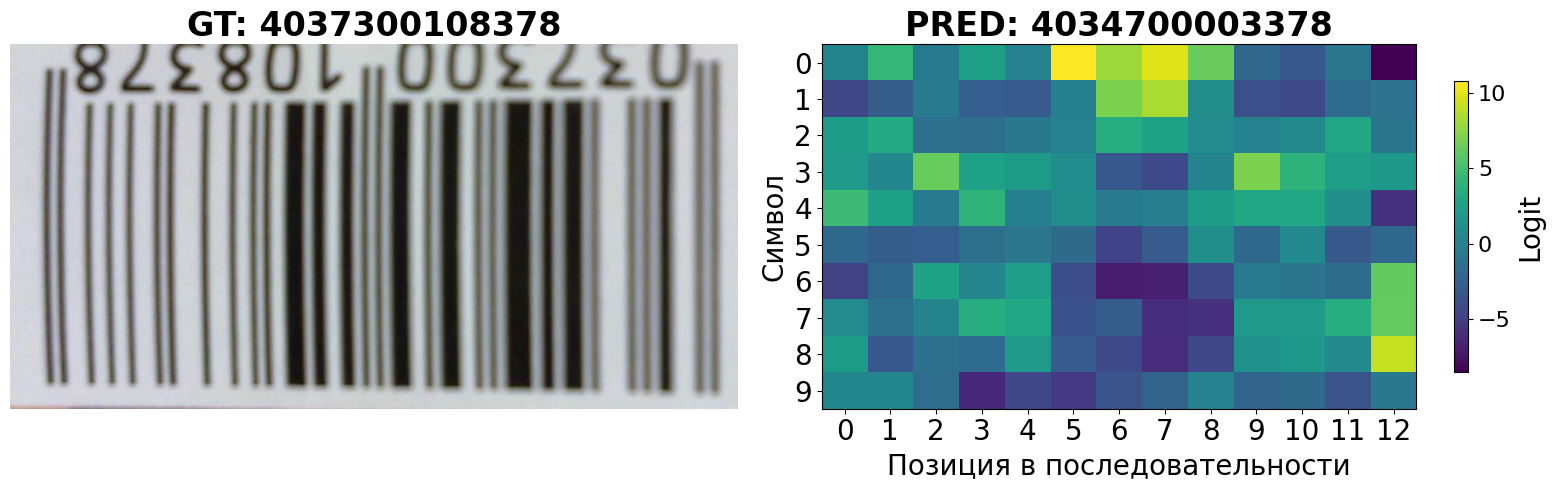

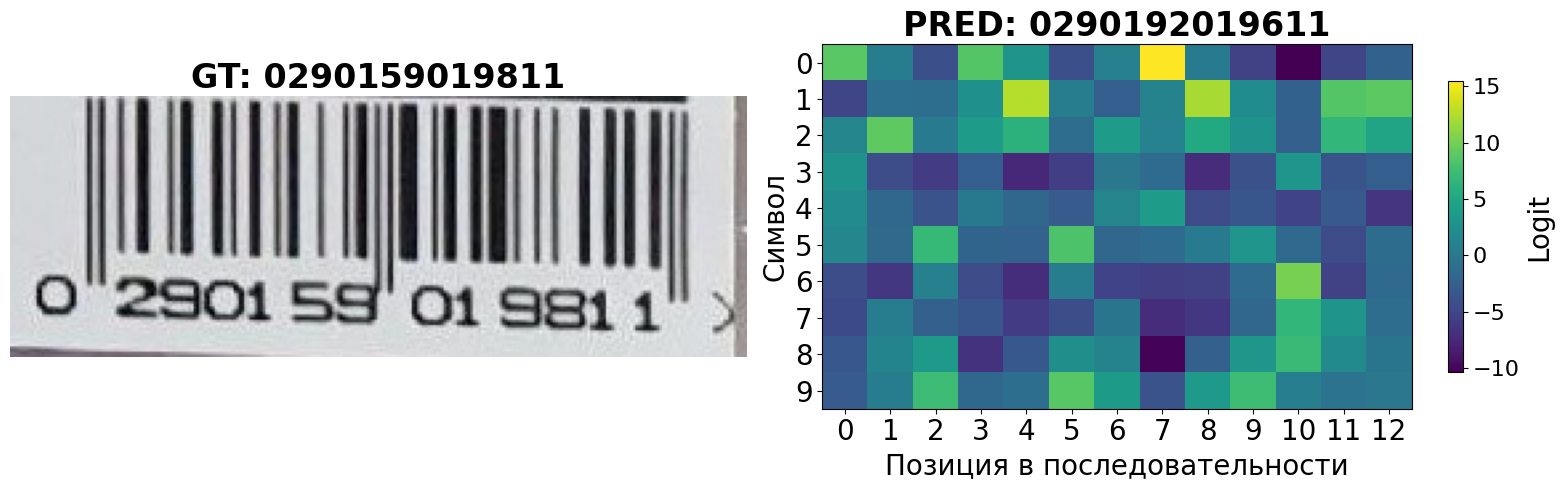

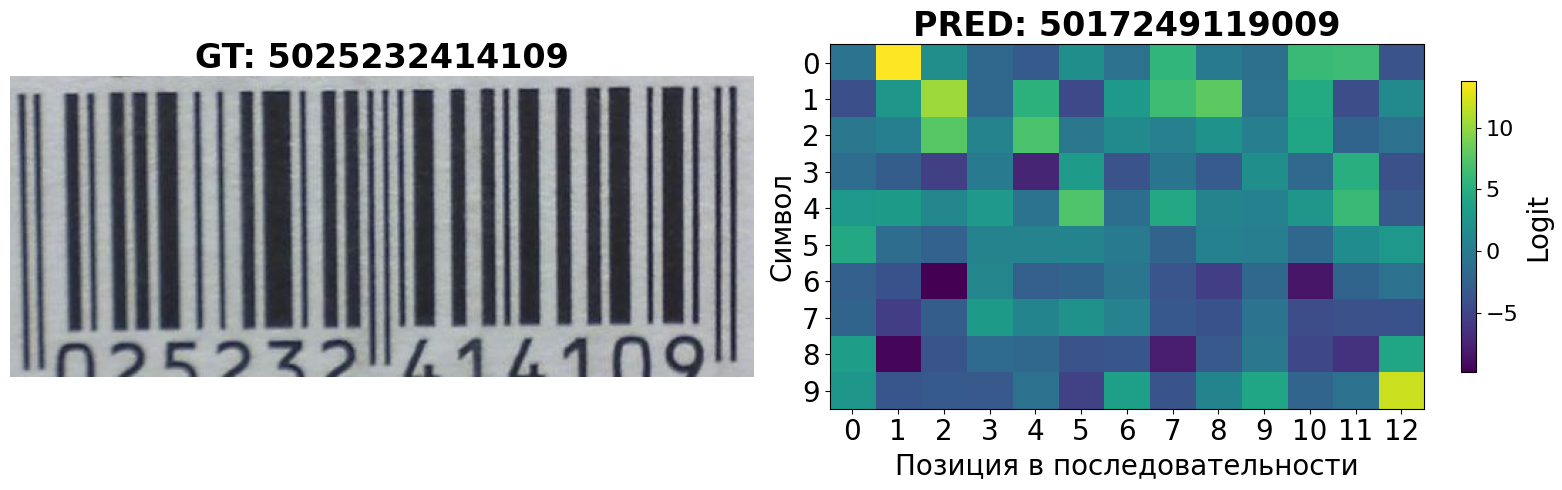

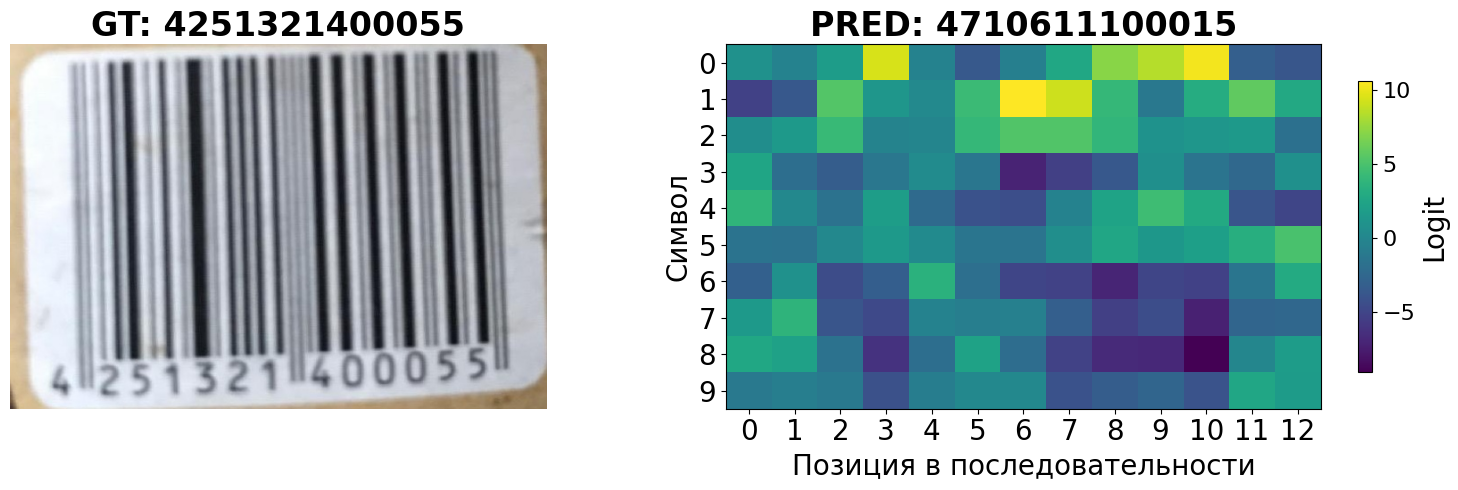

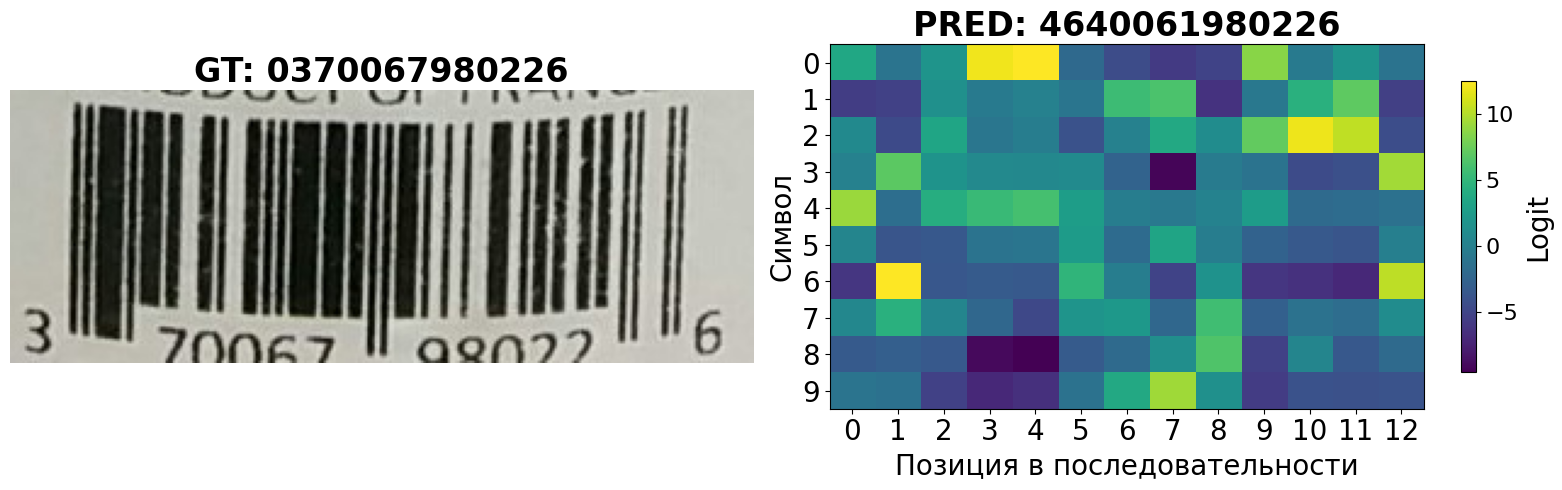

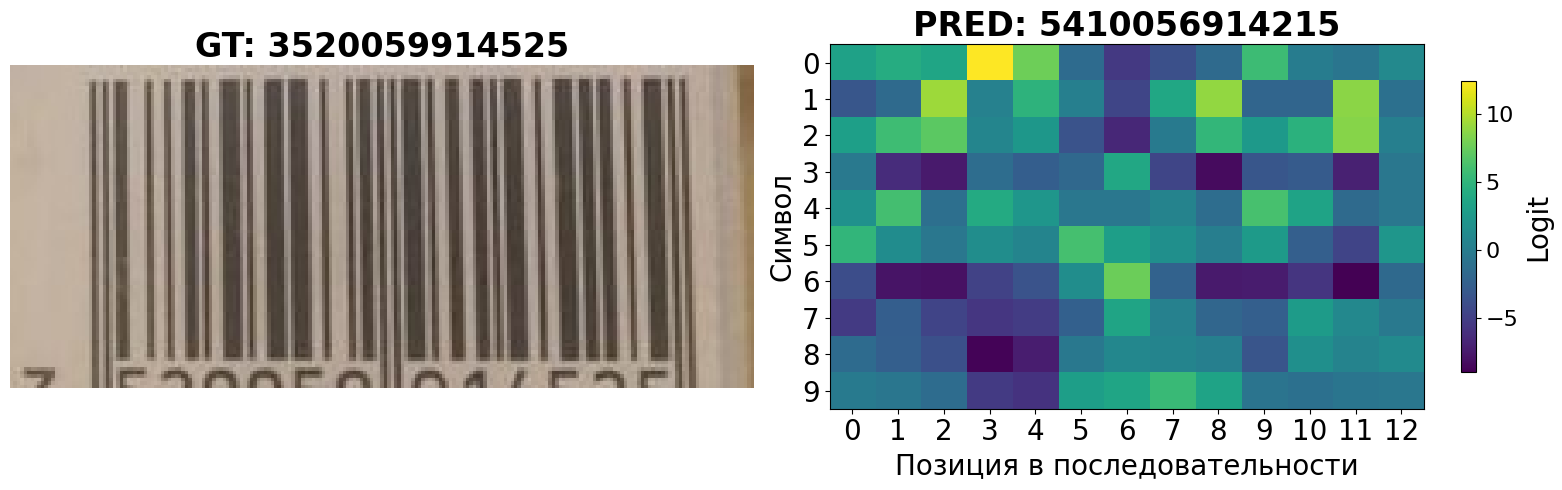

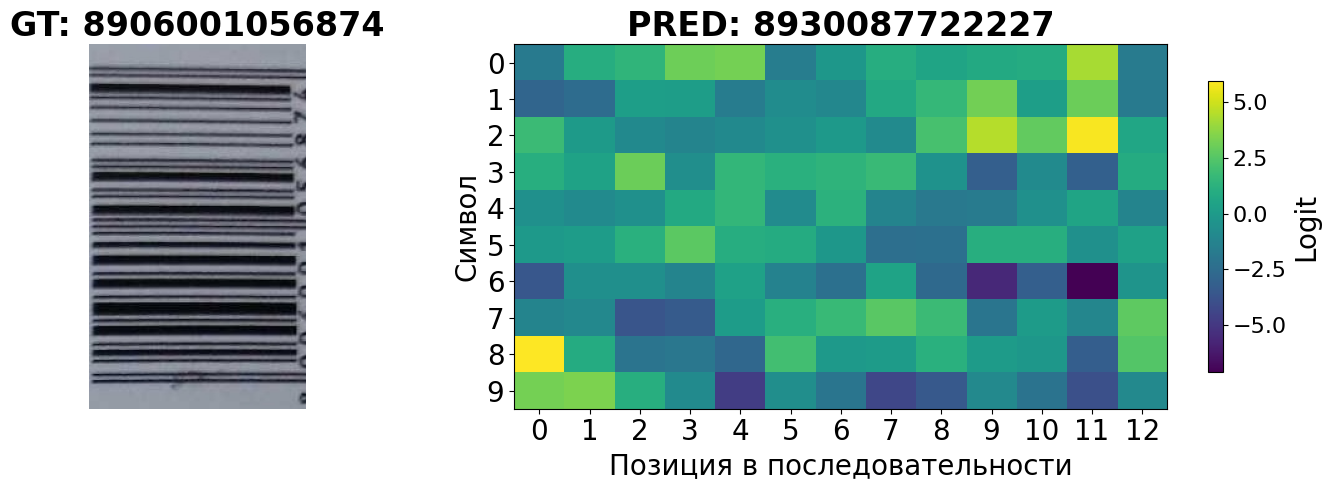

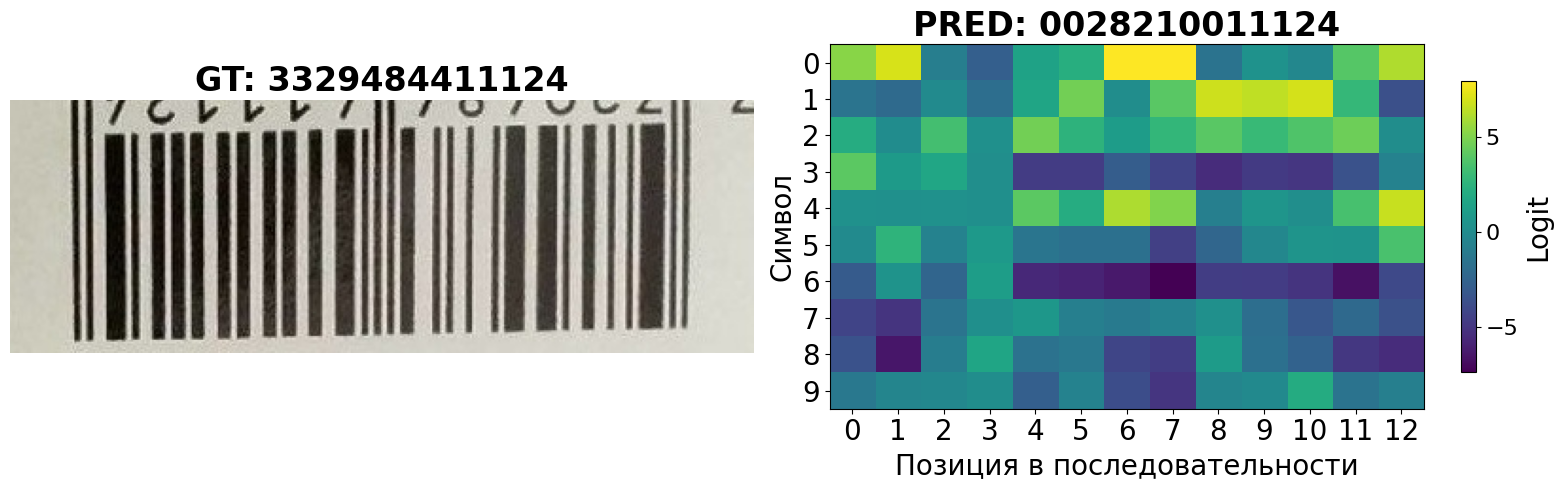

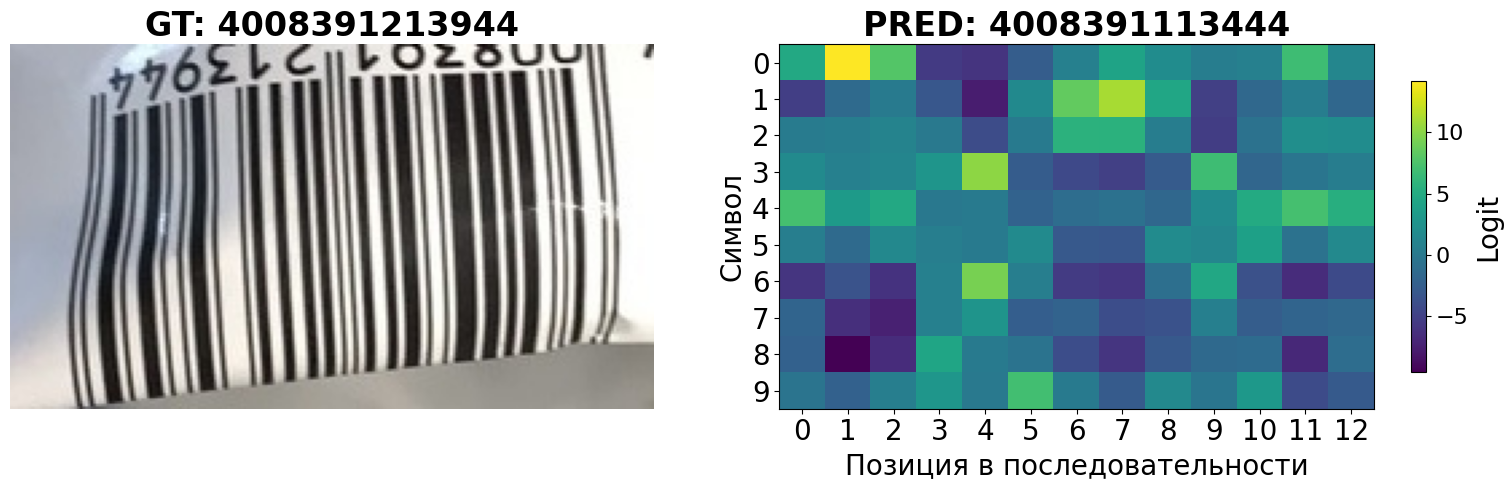

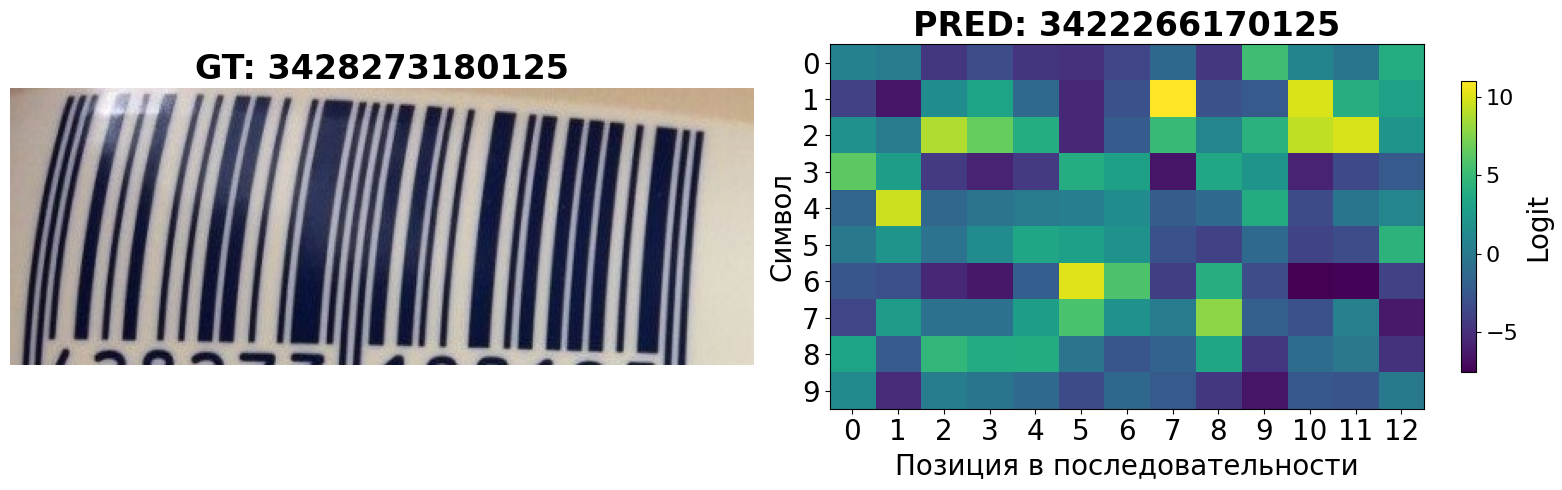

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Прогоняем батч через сеть
preds = classification_crnn(b['torch_images'].to(device)).cpu().detach()

# 2. Используем декодер для классификации
texts_pred = decode_classification(preds)

# 3. Для классификации алфавит состоит ровно из num_classes символов
y_ticks = list(alphabet) 

num_samples_to_show = min(10, len(b['text']))

for i in range(num_samples_to_show):
    # Создаем фигуру с фиксированным размером
    fig = plt.figure(figsize=(16, 5))
    
    # --- Левая часть: Исходное изображение ---
    ax1 = plt.subplot(1, 2, 1)
    pil_image = b['pil_images'][i]
    plt.imshow(pil_image)
    plt.axis('off')
    plt.title(f"GT: {b['text'][i]}", fontsize=24, fontweight='bold')
    
    # --- Правая часть: Тепловая карта предсказаний ---
    ax2 = plt.subplot(1, 2, 2)
    ax2.invert_yaxis()

    pred_i = preds[:, i, :].numpy()  # (13, 10)
    
    # Ключевое исправление: используем extent и aspect='auto'
    # extent=[xmin, xmax, ymin, ymax] задает границы отображения
    plt.imshow(pred_i.T, cmap='viridis', aspect='auto')

    # Настраиваем оси
    plt.yticks(range(pred_i.shape[1]), y_ticks, fontsize=20)
    plt.xticks(range(pred_i.shape[0]), fontsize=20)
    
    plt.xlabel('Позиция в последовательности', fontsize=20)
    plt.ylabel('Символ', fontsize=20)
    plt.title(f'PRED: {texts_pred[i]}', fontsize=24, fontweight='bold')

    cbar = plt.colorbar(label='Logit', shrink=0.8)

    # 1. Увеличиваем шрифт главного ярлыка (Logit)
    cbar.set_label('Logit', fontsize=20)
    
    # 2. Увеличиваем шрифт цифр (делений) на шкале
    cbar.ax.tick_params(labelsize=16)
    
    # Убираем белые поля вокруг subplots
    plt.tight_layout()
    plt.show()